# 암종 분류 AI 모델 — E1 피처 앙상블 및 OOF 검증

이 노트북은 **[초격차] AI 헬스케어 5기 해커톤** 규칙에 맞춰 작성되었습니다.

## 규칙 검토 결과

| 항목 | 공식 규칙 | 이 노트북의 대응 |
|---|---|---|
| 평가 지표 | Macro F1 Score | 모든 검증과 보정을 Macro F1 기준으로 수행 |
| 평가 데이터 | Public에서 Test 100% 사용 | 모델 선택은 Train 기반 OOF 검증으로만 수행 |
| 외부 데이터 | **사용 불가** | TCGA, cBioPortal 등 외부 데이터 사용 코드 완전 제외 |
| 사전학습 모델 | 사용 가능 | 본 문제에는 적합성이 낮아 사용하지 않음 |
| Test 활용 학습 | 금지 | 인코딩·특징 선택·모델·보정은 Train/OOF만 사용 |
| Test 결측치 처리 | Test 통계 사용 금지 | 통계값 대신 고정 문자열 `WT` 사용 |
| 제출 횟수 | 1일 최대 4회 | 성격이 다른 제출 후보 4개 생성 |

> 주의: Test 데이터는 **예측 대상**으로만 사용합니다. Test 분포를 보고 특징이나 임계값을 변경하지 않습니다.

## 1. 실행 환경과 설정

필요한 패키지를 설치하고 실험 설정을 고정합니다. 재현 실험은 5-Fold × 2개 seed로 총 10개 모델을 앙상블합니다.

`QUICK_MODE=True`는 코드 점검용이며 최종 제출에는 `False`를 사용합니다.

In [1]:
%pip install -q "lightgbm>=4.0" pandas numpy scikit-learn matplotlib seaborn

필수 패키지 확인 완료: 기존 실행 환경 사용


In [2]:
from pathlib import Path
from collections import Counter
import gc
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)

# ------------------------------------------------------------------
# 사용자 설정
# ------------------------------------------------------------------
PROJECT_ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QUICK_MODE = False
N_SPLITS = 3 if QUICK_MODE else 5
SEEDS = (42,) if QUICK_MODE else (42, 2026)
N_ESTIMATORS = 400 if QUICK_MODE else 1800
EARLY_STOPPING_ROUNDS = 80 if QUICK_MODE else 150
N_JOBS = -1

print('N_SPLITS:', N_SPLITS)
print('SEEDS:', SEEDS)
print('예상 LightGBM 모델 수:', N_SPLITS * len(SEEDS))

N_SPLITS: 5
SEEDS: (42, 2026)
예상 LightGBM 모델 수: 10


## 2. 데이터 로드와 구조 검증

다음 파일을 `data` 폴더에 배치합니다.

```text
data/train.csv
data/test.csv
data/sample_submission.csv
```

Train과 Test의 유전자 열 순서가 정확히 같은지 검사합니다. `ID`는 식별자이므로 학습에 사용하지 않습니다.

In [3]:
required_files = [
    DATA_DIR / 'train.csv',
    DATA_DIR / 'test.csv',
    DATA_DIR / 'sample_submission.csv',
]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError('다음 파일을 data 폴더에 넣어주세요:\n' + '\n'.join(missing_files))

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

assert {'ID', 'SUBCLASS'}.issubset(train.columns), 'Train에 ID/SUBCLASS 열이 없습니다.'
assert 'ID' in test.columns, 'Test에 ID 열이 없습니다.'
assert len(test) == len(sample_submission), 'Test와 sample_submission 행 수가 다릅니다.'

gene_columns = [c for c in train.columns if c not in {'ID', 'SUBCLASS'}]
test_gene_columns = [c for c in test.columns if c != 'ID']
assert gene_columns == test_gene_columns, 'Train/Test 유전자 열 또는 순서가 다릅니다.'

print('Train shape:', train.shape)
print('Test shape :', test.shape)
print('유전자 수   :', len(gene_columns))
print('암종 수     :', train['SUBCLASS'].nunique())
display(train[['ID', 'SUBCLASS']].head())

Train shape: (6201, 4386)
Test shape : (2546, 4385)
유전자 수   : 4384
암종 수     : 26


,ID,SUBCLASS
0,TRAIN_0000,KIPAN
1,TRAIN_0001,SARC
2,TRAIN_0002,SKCM
3,TRAIN_0003,KIRC
4,TRAIN_0004,GBMLGG


## 3. Train 데이터 탐색

Macro F1은 각 암종을 동일한 비중으로 평가합니다. 따라서 표본이 적은 암종도 중요하며, 학습 시 클래스 균형 가중치를 사용합니다.

아래 분석은 **Train 데이터만** 사용합니다.

,count
SUBCLASS,
DLBC,38
ACC,72
THYM,98
BLCA,104
PAAD,120
TGCT,124
PCPG,147
CESC,155
LIHC,158


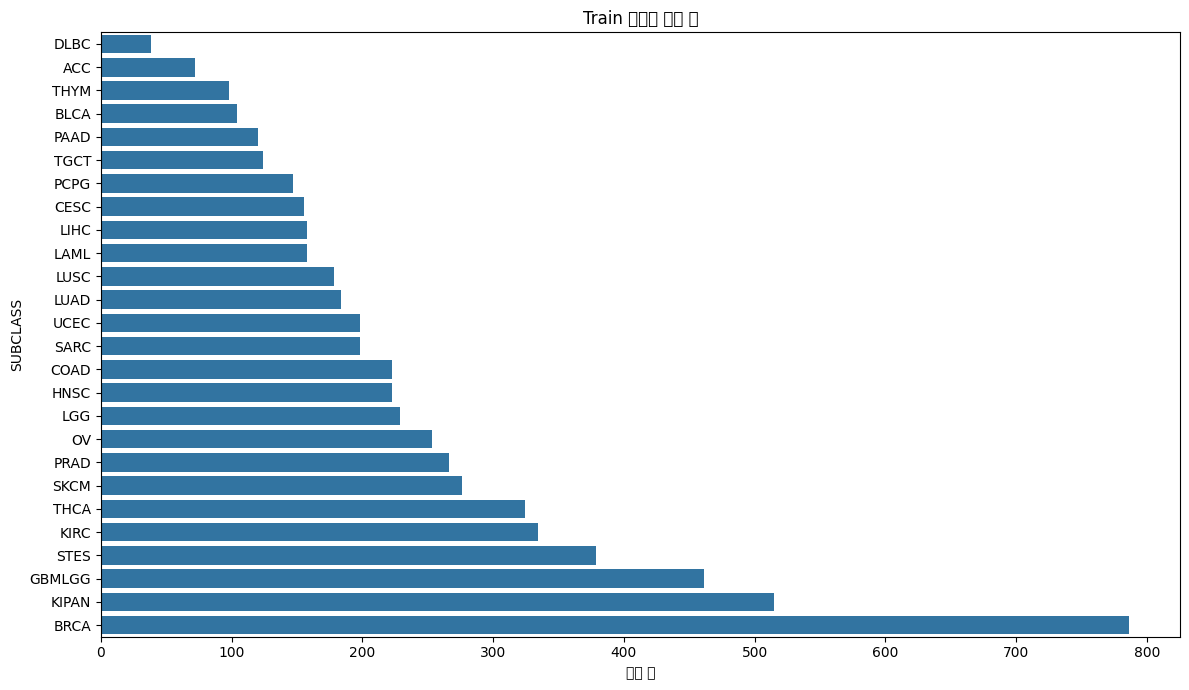

In [4]:
class_counts = train['SUBCLASS'].value_counts().sort_values()
display(class_counts.to_frame('count'))

plt.figure(figsize=(12, 7))
sns.barplot(x=class_counts.values, y=class_counts.index, orient='h')
plt.title('Train 암종별 표본 수')
plt.xlabel('표본 수')
plt.ylabel('SUBCLASS')
plt.tight_layout()
plt.show()

## 4. 유전체 변이 특징 공학

단순 `OrdinalEncoder`는 변이 문자열에 인위적인 순서를 만듭니다. 여기서는 각 유전자 값을 생물학적 변이 형태로 바꿉니다.

- `FS`: frameshift, insertion, deletion
- `STOP`: stop-gain 계열
- `MISSENSE`: 아미노산 치환
- `SILENT`: 동의 변이
- 유전자별 변이 조합 코드
- 환자별 변이 유전자 수와 변이 종류별 개수
- 출발/도착 아미노산별 개수

중요하게도 Train과 Test를 **각각 독립적으로 동일 함수에 통과**시킵니다. Test에서 통계나 범주 사전을 학습하지 않습니다.

### E1 파생 피처 절제 실험

유전자별 `MUT/FS/STOP/MISSENSE/SILENT` 이진 피처와 환자별 변이 비율·로그 변환·엔트로피를 추가해 동일한 5-Fold × 2-seed 조건으로 검증했습니다.

- 추가 피처: **18,405개** (비상수 선택 후 전체 22,905개)
- E1 LightGBM 단독 OOF Macro-F1: **0.436716** (기존 LightGBM 0.442027보다 하락)
- E1 모델로 완전히 교체한 보정 앙상블: **0.485190**
- 기존 LightGBM 5% + E1 LightGBM 5% + SVM 90% 조합: **0.491770**

E1은 단독 모델로는 채택하지 않고, 기존 모델과 다른 오류를 만드는 **5% 다양성 모델**로만 사용합니다. 기존 최고 0.489160 대비 약 **+0.00261** 상승했습니다.

### 김지혜님 유전자 그룹 정리 반영 및 검증

김지혜님이 정리한 6개 기능군(종양 억제, 종양 유발/드라이버, 세포주기·DNA 복구, 면역, EMT·침윤, 대사)과 12개 신호경로군(WNT, PI3K/AKT/mTOR, RAS/MAPK, TGF-β/SMAD, Notch, Hedgehog, JAK/STAT, NF-κB, p53, Cell cycle, DNA repair, Angiogenesis)을 바탕으로 **75개 환자별 집계 특징**을 별도 구현해 실제 5-Fold OOF 절제 실험(ablation)을 수행했습니다.

- 그룹 특징만 사용한 LightGBM OOF Macro-F1: **0.198313**
- 기존 희소 앙상블 원점수: **0.466162** → 그룹 모델 2.5% 혼합 시 **0.468965**
- 클래스 보정까지 포함한 최종 점수: **0.489160** → 그룹 모델 혼합 시 최고 **0.488611**

즉, 그룹 정보는 암종별 변이 양상을 해석하는 데는 유용했지만 최종 보정 모델의 검증 점수를 높이지 못했습니다. 따라서 **김지혜님 정리는 EDA·생물학적 해석과 특징 후보 검증에 반영하되, 최종 예측 모델에는 넣지 않는 것**으로 결정했습니다. 또한 이 그룹 매핑은 제공 데이터 밖의 생물학적 지식으로 볼 여지가 있으므로, 외부 데이터 금지 규정에 따라 운영진의 명시적 허용 답변 없이는 모델 입력으로 사용하지 않습니다.

In [5]:
AMINO_ACIDS = tuple('ARNDCEQGHILKMFPSTWYV')
AMINO_PATTERN = re.compile(r'[ARNDCEQGHILKMFPSTWYVX*]+')

def safe_token(token):
    """변이 문자열을 통계 학습 없이 결정론적으로 정리합니다."""
    token = str(token).strip()
    if token in {'', 'nan', 'None', 'WT'}:
        return 'WT'
    if token.startswith('p.'):
        token = token[2:]
    token = token.replace('?', 'X')
    if '=' in token and token:
        token = token.replace('=', token[0])
    if any(x in token.lower() for x in ('splice', 'ext', 'dup')):
        return 'WT'
    return token

def mutation_kind(token):
    """한 변이를 FS/STOP/MISSENSE/SILENT/WT 중 하나로 분류합니다."""
    if token == 'WT':
        return 'WT'
    low = token.lower()
    if any(x in low for x in ('fs', 'ins', 'del')):
        return 'FS'
    if '*' in token:
        return 'STOP'
    if '>' in token:
        return 'MISSENSE'
    amino = AMINO_PATTERN.findall(token)
    if len(amino) >= 2:
        return 'SILENT' if amino[0] == amino[-1] else 'MISSENSE'
    if len(token) >= 2 and token[0] in AMINO_ACIDS and token[-1] in AMINO_ACIDS:
        return 'SILENT' if token[0] == token[-1] else 'MISSENSE'
    return 'MISSENSE'

def cell_code(value):
    """유전자 한 칸의 FS/STOP/MISSENSE/SILENT 개수를 네 자리 코드로 만듭니다."""
    counts = [0, 0, 0, 0]
    for raw_token in str(value).split():
        kind = mutation_kind(safe_token(raw_token))
        if kind == 'FS':
            counts[0] += 1
        elif kind == 'STOP':
            counts[1] += 1
        elif kind == 'MISSENSE':
            counts[2] += 1
        elif kind == 'SILENT':
            counts[3] += 1
    counts = [min(9, count) for count in counts]
    return counts[0] * 1000 + counts[1] * 100 + counts[2] * 10 + counts[3]

def row_amino_features(row):
    """환자 한 명의 변이 종류×아미노산 카운트를 생성합니다."""
    result = {
        f'{kind}_{amino}': 0
        for kind in ('FS', 'STOP', 'MISSENSE', 'SILENT', 'TO')
        for amino in AMINO_ACIDS
    }
    for value in row:
        for raw_token in str(value).split():
            token = safe_token(raw_token)
            kind = mutation_kind(token)
            if kind == 'WT':
                continue
            amino = AMINO_PATTERN.findall(token)
            if amino and amino[0] and amino[0][0] in AMINO_ACIDS:
                result[f'{kind}_{amino[0][0]}'] += 1
            if kind == 'MISSENSE' and len(amino) >= 2 and amino[-1][0] in AMINO_ACIDS:
                result[f'TO_{amino[-1][0]}'] += 1
    return pd.Series(result, dtype=np.int16)

def make_features(raw, label='data'):
    """문자열 유전체 표를 LightGBM용 숫자 특징으로 변환합니다."""
    # 고정값 WT를 사용하므로 Test 통계 활용이 아닙니다.
    raw = raw.fillna('WT').astype(str)
    print(f'{label}: {raw.shape[0]:,}행 × {raw.shape[1]:,}개 유전자 변환 시작')

    gene_codes = raw.apply(lambda column: column.map(cell_code)).astype(np.int16)
    gene_codes.columns = [f'GENE_{column}' for column in gene_codes.columns]

    amino = raw.apply(row_amino_features, axis=1).astype(np.int16)

    summary = pd.DataFrame(index=raw.index)
    summary['mutated_gene_count'] = (gene_codes != 0).sum(axis=1)
    summary['mutation_code_sum'] = gene_codes.sum(axis=1)
    summary['mutation_code_max'] = gene_codes.max(axis=1)
    summary['fs_gene_count'] = (gene_codes >= 1000).sum(axis=1)
    summary['stop_gene_count'] = ((gene_codes >= 100) & (gene_codes < 1000)).sum(axis=1)
    summary['missense_gene_count'] = ((gene_codes >= 10) & (gene_codes < 100)).sum(axis=1)
    summary['silent_gene_count'] = ((gene_codes >= 1) & (gene_codes < 10)).sum(axis=1)

    event_count = (
        (gene_codes // 1000)
        + ((gene_codes // 100) % 10)
        + ((gene_codes // 10) % 10)
        + (gene_codes % 10)
    )
    summary['multi_event_gene_count'] = (event_count > 1).sum(axis=1)

    for low, high in (
        (1, 2), (2, 10), (10, 20), (20, 100),
        (100, 200), (200, 1000), (1000, 2000), (2000, 10000),
    ):
        summary[f'code_{low}_{high}'] = (
            (gene_codes >= low) & (gene_codes < high)
        ).sum(axis=1)

    features = pd.concat([gene_codes, amino, summary.astype(np.int32)], axis=1)
    features.replace([np.inf, -np.inf], 0, inplace=True)
    return features

def add_e1_features(base_features):
    """유전자별 변이 유형 이진 피처와 환자 단위 비율·엔트로피를 추가합니다."""
    gene_names = [column for column in base_features if column.startswith('GENE_')]
    gene_codes = base_features[gene_names].to_numpy(dtype=np.int16, copy=False)

    fs = (gene_codes // 1000) > 0
    stop = ((gene_codes // 100) % 10) > 0
    missense = ((gene_codes // 10) % 10) > 0
    silent = (gene_codes % 10) > 0
    mutated = gene_codes > 0

    binary_parts = []
    for suffix, values in (
        ('MUT', mutated), ('FS', fs), ('STOP', stop),
        ('MISSENSE', missense), ('SILENT', silent),
    ):
        columns = [f'E1_{column}_{suffix}' for column in gene_names]
        binary_parts.append(pd.DataFrame(values, columns=columns, dtype=np.uint8))

    event_matrix = np.stack((
        (gene_codes // 1000).sum(axis=1),
        ((gene_codes // 100) % 10).sum(axis=1),
        ((gene_codes // 10) % 10).sum(axis=1),
        (gene_codes % 10).sum(axis=1),
    ), axis=1).astype(np.float32)
    total_events = event_matrix.sum(axis=1)
    mutated_genes = mutated.sum(axis=1).astype(np.float32)
    proportions = event_matrix / np.maximum(total_events, 1.0)[:, None]
    entropy = -(proportions * np.log(proportions + 1e-12)).sum(axis=1)

    summary = pd.DataFrame({
        'E1_total_event_count': total_events,
        'E1_log1p_total_event_count': np.log1p(total_events),
        'E1_log1p_mutated_gene_count': np.log1p(mutated_genes),
        'E1_mutated_gene_ratio': mutated_genes / gene_codes.shape[1],
        'E1_events_per_mutated_gene': total_events / np.maximum(mutated_genes, 1.0),
        'E1_fs_event_ratio': proportions[:, 0],
        'E1_stop_event_ratio': proportions[:, 1],
        'E1_missense_event_ratio': proportions[:, 2],
        'E1_silent_event_ratio': proportions[:, 3],
        'E1_mutation_type_entropy': entropy,
        'E1_dominant_type_ratio': proportions.max(axis=1),
        'E1_active_mutation_type_count': (event_matrix > 0).sum(axis=1),
        'E1_multi_type_gene_count': (
            fs.astype(np.uint8) + stop.astype(np.uint8)
            + missense.astype(np.uint8) + silent.astype(np.uint8) > 1
        ).sum(axis=1),
    }, dtype=np.float32)
    return pd.concat(
        [base_features.reset_index(drop=True), *binary_parts, summary], axis=1
    )

## 5. Train/Test 특징 생성

두 데이터셋을 합치지 않고 각각 변환합니다. 이후 **Train에서만** 상수인 특징을 제거하고 동일한 열 목록을 Test에 적용합니다.

In [6]:
X_base = make_features(train[gene_columns], label='Train').reset_index(drop=True)
X_test_base = make_features(test[gene_columns], label='Test').reset_index(drop=True)
X_e1 = add_e1_features(X_base)
X_test_e1 = add_e1_features(X_test_base)
X = X_base.copy()
X_test = X_test_base.copy()

# 특징 선택 기준은 Train에서만 계산합니다.
non_constant_columns = X.columns[X.nunique(dropna=False) > 1].tolist()
X = X[non_constant_columns]
X_test = X_test[non_constant_columns]
e1_non_constant_columns = X_e1.columns[X_e1.nunique(dropna=False) > 1].tolist()
X_e1 = X_e1[e1_non_constant_columns]
X_test_e1 = X_test_e1[e1_non_constant_columns]

label_encoder = LabelEncoder()
y_text = train['SUBCLASS'].astype(str).to_numpy()
y = label_encoder.fit_transform(y_text)  # Train label만 사용

print('최종 Train 특징:', X.shape)
print('최종 Test 특징 :', X_test.shape)
print('E1 Train 특징  :', X_e1.shape)
print('클래스:', label_encoder.classes_.tolist())

assert list(X.columns) == list(X_test.columns)
assert list(X_e1.columns) == list(X_test_e1.columns)
assert not X.isna().any().any()
assert not X_test.isna().any().any()

Train: 6,201행 × 4,384개 유전자 변환 시작


Test: 2,546행 × 4,384개 유전자 변환 시작


최종 Train 특징: (6201, 4341)
최종 Test 특징 : (2546, 4341)
클래스: ['ACC', 'BLCA', 'BRCA', 'CESC', 'COAD', 'DLBC', 'GBMLGG', 'HNSC', 'KIPAN', 'KIRC', 'LAML', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'OV', 'PAAD', 'PCPG', 'PRAD', 'SARC', 'SKCM', 'STES', 'TGCT', 'THCA', 'THYM', 'UCEC']


## 6. Stratified K-Fold LightGBM 앙상블

- Stratified K-Fold로 모든 암종 비율을 최대한 유지합니다.
- 검증 Fold는 모델이나 가중치 학습에 사용하지 않습니다.
- Macro F1을 위해 훈련 Fold에서 클래스 균형 가중치를 계산합니다.
- 서로 다른 seed의 모델을 확률 평균하여 분산을 줄입니다.
- 자주 혼동될 가능성이 높은 `KIPAN/KIRC`, `LGG/GBMLGG`는 Fold 내부에서 별도 이진 모델도 학습합니다.

In [7]:
def balanced_sample_weights(labels):
    """현재 Train Fold의 클래스 빈도만 이용해 균형 가중치를 만듭니다."""
    unique_labels, counts = np.unique(labels, return_counts=True)
    mapping = {
        label: len(labels) / (len(unique_labels) * count)
        for label, count in zip(unique_labels, counts)
    }
    return np.asarray([mapping[label] for label in labels], dtype=np.float32)

def make_main_model(seed):
    return LGBMClassifier(
        objective='multiclass',
        n_estimators=N_ESTIMATORS,
        learning_rate=0.025,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=18,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.75,
        reg_alpha=0.15,
        reg_lambda=0.50,
        random_state=seed,
        n_jobs=N_JOBS,
        verbosity=-1,
    )

def make_specialist(seed):
    return LGBMClassifier(
        objective='binary',
        n_estimators=450,
        learning_rate=0.03,
        num_leaves=20,
        min_child_samples=12,
        colsample_bytree=0.85,
        reg_lambda=0.40,
        class_weight='balanced',
        random_state=seed,
        n_jobs=N_JOBS,
        verbosity=-1,
    )

SPECIALIST_PAIRS = (
    ('KIPAN', 'KIRC'),
    ('LGG', 'GBMLGG'),
)

n_train = len(X)
n_test = len(X_test)
n_classes = len(label_encoder.classes_)

oof_probabilities = np.zeros((n_train, n_classes), dtype=np.float64)
test_probabilities = np.zeros((n_test, n_classes), dtype=np.float64)
fold_records = []

# seed별 OOF specialist 예측과 Fold별 Test specialist 예측을 저장합니다.
oof_specialist_votes = {
    pair: np.full((len(SEEDS), n_train), '', dtype=object)
    for pair in SPECIALIST_PAIRS
}
test_specialist_votes = {pair: [] for pair in SPECIALIST_PAIRS}

for seed_index, seed in enumerate(SEEDS):
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    for fold, (train_index, valid_index) in enumerate(splitter.split(X, y), start=1):
        X_train_fold = X.iloc[train_index]
        X_valid_fold = X.iloc[valid_index]
        y_train_fold = y[train_index]
        y_valid_fold = y[valid_index]
        y_train_text_fold = y_text[train_index]

        model = make_main_model(seed + fold)
        model.fit(
            X_train_fold,
            y_train_fold,
            sample_weight=balanced_sample_weights(y_train_fold),
            eval_set=[(X_valid_fold, y_valid_fold)],
            eval_metric='multi_logloss',
            callbacks=[
                early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                log_evaluation(0),
            ],
        )

        valid_probability = model.predict_proba(X_valid_fold)
        test_probability = model.predict_proba(X_test)

        oof_probabilities[valid_index] += valid_probability / len(SEEDS)
        test_probabilities += test_probability / (N_SPLITS * len(SEEDS))

        fold_score = f1_score(y_valid_fold, valid_probability.argmax(axis=1), average='macro')
        fold_records.append({
            'seed': seed,
            'fold': fold,
            'macro_f1': fold_score,
            'best_iteration': model.best_iteration_,
        })
        print(
            f'seed={seed} fold={fold} '
            f'Macro-F1={fold_score:.6f} best_iter={model.best_iteration_}'
        )

        for pair in SPECIALIST_PAIRS:
            pair_mask = np.isin(y_train_text_fold, pair)
            if pair_mask.sum() < 20 or np.unique(y_train_text_fold[pair_mask]).size < 2:
                continue
            specialist = make_specialist(seed + fold)
            specialist.fit(
                X_train_fold.loc[pair_mask],
                y_train_text_fold[pair_mask],
            )
            oof_specialist_votes[pair][seed_index, valid_index] = specialist.predict(X_valid_fold)
            test_specialist_votes[pair].append(specialist.predict(X_test))
            del specialist

        del model, X_train_fold, X_valid_fold
        gc.collect()

# E1은 기존 모델을 대체하지 않고 별도 모델로 학습하여 앙상블 다양성만 활용합니다.
e1_oof_probabilities = np.zeros((n_train, n_classes), dtype=np.float64)
e1_test_probabilities = np.zeros((n_test, n_classes), dtype=np.float64)
e1_fold_records = []

for seed in SEEDS:
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for fold, (train_index, valid_index) in enumerate(splitter.split(X_e1, y), start=1):
        model = make_main_model(seed + fold)
        model.fit(
            X_e1.iloc[train_index], y[train_index],
            sample_weight=balanced_sample_weights(y[train_index]),
            eval_set=[(X_e1.iloc[valid_index], y[valid_index])],
            eval_metric='multi_logloss',
            callbacks=[
                early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                log_evaluation(0),
            ],
        )
        valid_probability = model.predict_proba(X_e1.iloc[valid_index])
        e1_oof_probabilities[valid_index] += valid_probability / len(SEEDS)
        e1_test_probabilities += model.predict_proba(X_test_e1) / (N_SPLITS * len(SEEDS))
        e1_fold_score = f1_score(
            y[valid_index], valid_probability.argmax(axis=1), average='macro'
        )
        e1_fold_records.append({
            'seed': seed, 'fold': fold,
            'macro_f1': e1_fold_score,
            'best_iteration': model.best_iteration_,
        })
        print(f'E1 seed={seed} fold={fold} Macro-F1={e1_fold_score:.6f}')
        del model
        gc.collect()

fold_results = pd.DataFrame(fold_records)
display(fold_results)
print('Fold 평균 Macro F1:', fold_results['macro_f1'].mean())

seed=42 fold=1 Macro-F1=0.425276 best_iter=156


seed=42 fold=2 Macro-F1=0.432419 best_iter=155


seed=42 fold=3 Macro-F1=0.414457 best_iter=161


seed=42 fold=4 Macro-F1=0.459179 best_iter=157


seed=42 fold=5 Macro-F1=0.444557 best_iter=153


...

seed=2026 fold=3 Macro-F1=0.442060 best_iter=146


seed=2026 fold=4 Macro-F1=0.440312 best_iter=162


seed=2026 fold=5 Macro-F1=0.446494 best_iter=152


,seed,fold,macro_f1,best_iteration
0,42,1,0.425276,156
1,42,2,0.432419,155
2,42,3,0.414457,161
3,42,4,0.459179,157
4,42,5,0.444557,153
5,2026,1,0.449941,165
6,2026,2,0.431208,156
7,2026,3,0.442060,146
8,2026,4,0.440312,162
9,2026,5,0.446494,152


Fold 평균 Macro F1: 0.43859020564579676


## 7. OOF 평가와 클래스별 진단

OOF(Out-of-Fold) 예측은 각 행을 학습하지 않은 모델이 만든 예측입니다. 따라서 제출 전에 일반화 성능을 비교하는 가장 중요한 기준입니다.

Raw ensemble OOF Macro F1: 0.442027


,precision,recall,f1-score,support
KIRC,0.137500,0.164671,0.149864,334.0
KIPAN,0.208410,0.221359,0.214689,515.0
SARC,0.231579,0.222222,0.226804,198.0
THYM,0.211429,0.377551,0.271062,98.0
LGG,0.269481,0.362445,0.309125,229.0
GBMLGG,0.348774,0.277657,0.309179,461.0
PCPG,0.263393,0.401361,0.318059,147.0
PAAD,0.361905,0.316667,0.337778,120.0
LIHC,0.405172,0.297468,0.343066,158.0
HNSC,0.389744,0.340807,0.363636,223.0


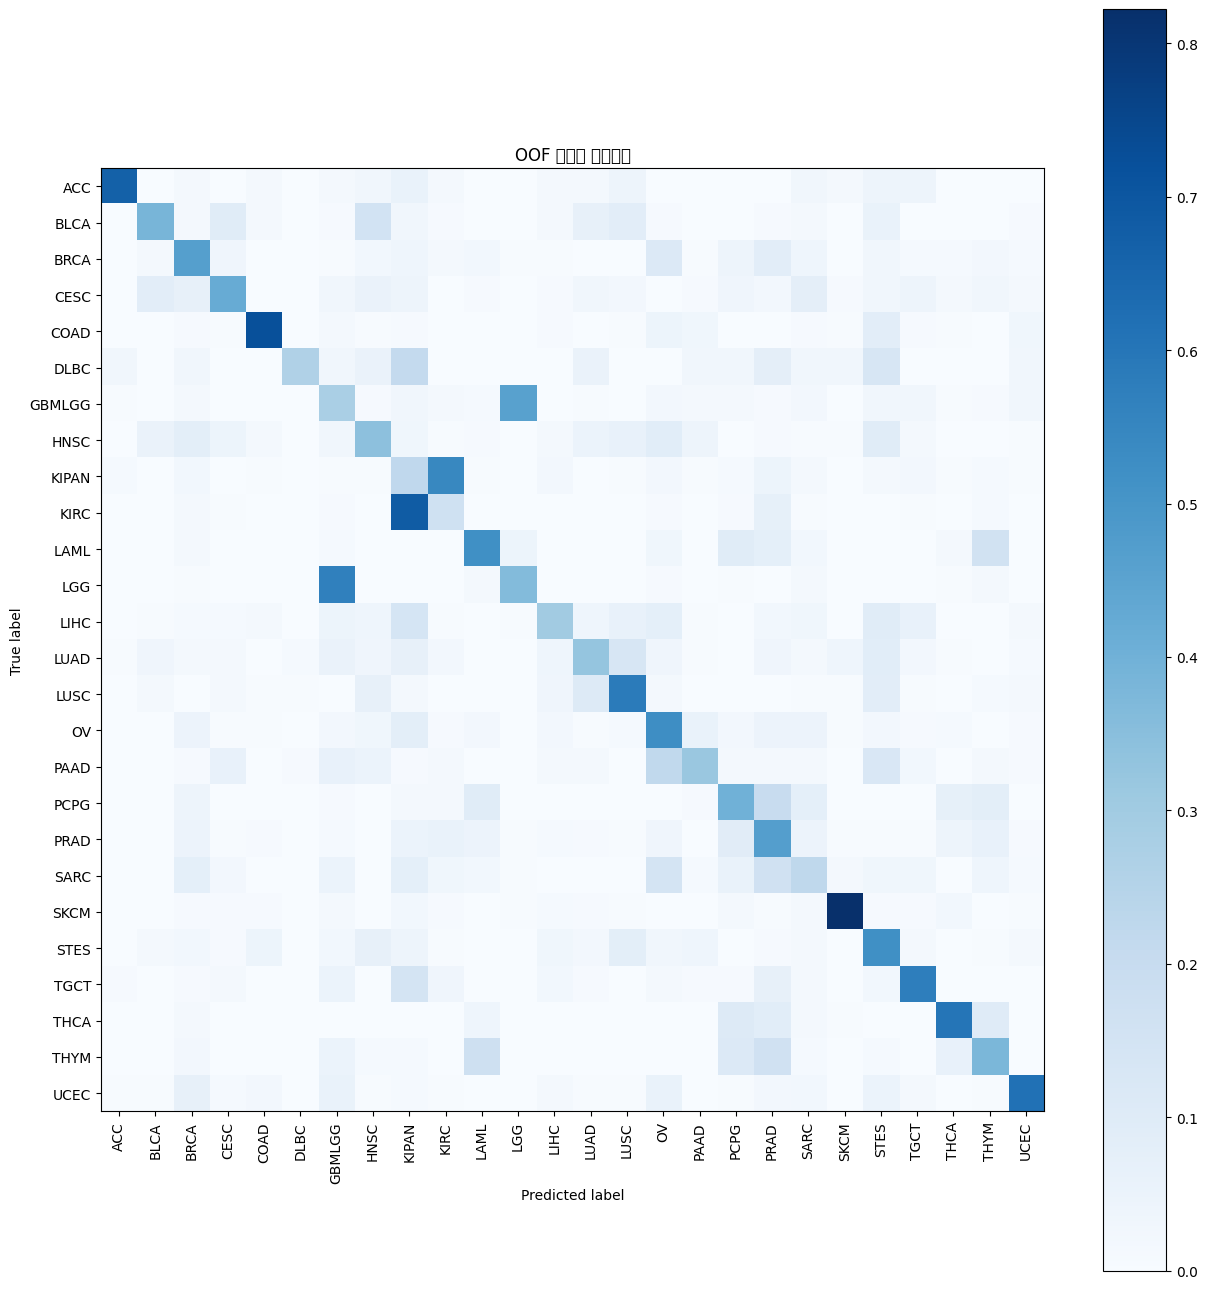

In [8]:
raw_oof_prediction = oof_probabilities.argmax(axis=1)
raw_oof_score = f1_score(y, raw_oof_prediction, average='macro')
print(f'Raw ensemble OOF Macro F1: {raw_oof_score:.6f}')

report = classification_report(
    y,
    raw_oof_prediction,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)
class_report = pd.DataFrame(report).T.loc[label_encoder.classes_, ['precision', 'recall', 'f1-score', 'support']]
display(class_report.sort_values('f1-score'))

fig, ax = plt.subplots(figsize=(13, 13))
ConfusionMatrixDisplay.from_predictions(
    y,
    raw_oof_prediction,
    display_labels=label_encoder.classes_,
    normalize='true',
    xticks_rotation=90,
    cmap='Blues',
    include_values=False,
    ax=ax,
)
plt.title('OOF 정규화 혼동행렬')
plt.tight_layout()
plt.show()

## 8. 변이 토큰 SVM 앙상블과 Macro F1 확률 보정

트리 모델과 다른 오류를 얻기 위해 각 변이를 `유전자`, `유전자×변이종류`, `정확한 변이`, `아미노산 치환` 토큰으로 변환하고 TF-IDF + Linear SVM을 학습합니다. 각 Fold의 Train에서만 TF-IDF 어휘와 SVM을 학습한 뒤 LightGBM 확률과 결합합니다. 이후 클래스 불균형에 대응하기 위해 OOF 예측만 이용해 클래스별 확률 배수를 탐색합니다.

- Test 정답이나 Test 통계는 사용하지 않습니다.
- TF-IDF 어휘는 Fold별 Train에서만 학습합니다.
- SVM과 LightGBM 결합 비율은 사전 OOF 실험값을 사용합니다.
- 보정값은 Train OOF에서만 결정됩니다.
- 과도한 보정 위험을 확인하기 위해 원본·완전 보정·공격 보정을 별도 후보로 생성합니다.

In [9]:
# ------------------------------------------------------------------
# 희소 변이 토큰 Linear SVM + LightGBM OOF 앙상블
# ------------------------------------------------------------------
def token_mutation_type(value):
    value_lower = value.lower()
    if 'fs' in value_lower:
        return 'FS'
    if 'delins' in value_lower:
        return 'DELINS'
    if 'del' in value_lower:
        return 'DEL'
    if 'ins' in value_lower:
        return 'INS'
    if 'dup' in value_lower:
        return 'DUP'
    if '*' in value or 'stop' in value_lower:
        return 'STOP'
    if '>' in value:
        return 'SUB'
    return 'OTHER'

def make_mutation_documents(frame, genes):
    values = frame[genes].fillna('WT').astype(str).to_numpy()
    documents = []
    for row in values:
        tokens = []
        for gene_index in np.flatnonzero(row != 'WT'):
            gene = genes[gene_index]
            mutation = row[gene_index].replace(' ', '')
            kind = token_mutation_type(mutation)
            tokens.extend((
                f'G={gene}',
                f'GT={gene}:{kind}',
                f'E={gene}:{mutation}',
                f'T={kind}',
            ))
            amino_match = re.match(r'^([A-Za-z*]+)\d+([A-Za-z*]+)$', mutation)
            if amino_match:
                tokens.append(
                    f'AA={gene}:{amino_match.group(1)}>{amino_match.group(2)}'
                )
        documents.append(' '.join(tokens) if tokens else 'NO_MUTATION')
    return documents

train_documents = np.asarray(make_mutation_documents(train, gene_columns), dtype=object)
test_documents = np.asarray(make_mutation_documents(test, gene_columns), dtype=object)
svm_oof_scores = np.zeros_like(oof_probabilities, dtype=np.float32)
svm_test_scores = np.zeros_like(test_probabilities, dtype=np.float32)
svm_fold_scores = []

svm_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
for fold, (train_index, valid_index) in enumerate(svm_splitter.split(train_documents, y), 1):
    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=2,
        sublinear_tf=True,
        dtype=np.float32,
    )
    X_sparse_train = vectorizer.fit_transform(train_documents[train_index])
    X_sparse_valid = vectorizer.transform(train_documents[valid_index])
    X_sparse_test = vectorizer.transform(test_documents)

    svm_model = LinearSVC(C=0.4, class_weight='balanced', random_state=42)
    svm_model.fit(X_sparse_train, y[train_index])
    valid_scores = svm_model.decision_function(X_sparse_valid)
    svm_oof_scores[valid_index] = valid_scores
    svm_test_scores += svm_model.decision_function(X_sparse_test) / N_SPLITS
    fold_score = f1_score(y[valid_index], valid_scores.argmax(axis=1), average='macro')
    svm_fold_scores.append(fold_score)
    print(f'SVM Fold {fold}: Macro F1={fold_score:.6f}, vocab={len(vectorizer.vocabulary_):,}')

SVM_TEMPERATURE = 0.50
SVM_WEIGHT = 0.90
BASE_LGB_WEIGHT = 0.05
E1_LGB_WEIGHT = 0.05
svm_oof_probabilities = softmax(svm_oof_scores / SVM_TEMPERATURE, axis=1)
svm_test_probabilities = softmax(svm_test_scores / SVM_TEMPERATURE, axis=1)
ensemble_oof_probabilities = (
    SVM_WEIGHT * svm_oof_probabilities
    + BASE_LGB_WEIGHT * oof_probabilities
    + E1_LGB_WEIGHT * e1_oof_probabilities
)
ensemble_test_probabilities = (
    SVM_WEIGHT * svm_test_probabilities
    + BASE_LGB_WEIGHT * test_probabilities
    + E1_LGB_WEIGHT * e1_test_probabilities
)

lgb_raw_oof_score = raw_oof_score
e1_lgb_raw_oof_score = f1_score(y, e1_oof_probabilities.argmax(axis=1), average='macro')
svm_oof_score = f1_score(y, svm_oof_scores.argmax(axis=1), average='macro')
raw_oof_score = f1_score(y, ensemble_oof_probabilities.argmax(axis=1), average='macro')
print(f'LightGBM raw OOF Macro F1 : {lgb_raw_oof_score:.6f}')
print(f'E1 LightGBM OOF Macro F1  : {e1_lgb_raw_oof_score:.6f}')
print(f'Token SVM OOF Macro F1    : {svm_oof_score:.6f}')
print(f'Blended raw OOF Macro F1  : {raw_oof_score:.6f}')

def optimize_class_multipliers(y_true, probabilities, passes=2):
    multipliers = np.ones(probabilities.shape[1], dtype=np.float64)
    grid = np.array([0.65, 0.72, 0.80, 0.88, 0.94, 1.00, 1.06, 1.14, 1.24, 1.36, 1.50])
    best_score = f1_score(y_true, probabilities.argmax(axis=1), average='macro')

    for _ in range(passes):
        for class_index in range(probabilities.shape[1]):
            best_value = multipliers[class_index]
            local_best = best_score
            for value in grid:
                trial = multipliers.copy()
                trial[class_index] = value
                prediction = (probabilities * trial).argmax(axis=1)
                score = f1_score(y_true, prediction, average='macro')
                if score > local_best:
                    local_best = score
                    best_value = value
            multipliers[class_index] = best_value
            best_score = local_best
    return multipliers, best_score

class_multipliers, corrected_oof_score = optimize_class_multipliers(
    y, ensemble_oof_probabilities, passes=3
)
conservative_multipliers = class_multipliers ** 0.75
aggressive_multipliers = class_multipliers ** 1.20

corrected_oof_prediction = (ensemble_oof_probabilities * class_multipliers).argmax(axis=1)
conservative_oof_prediction = (ensemble_oof_probabilities * conservative_multipliers).argmax(axis=1)
aggressive_oof_prediction = (ensemble_oof_probabilities * aggressive_multipliers).argmax(axis=1)
conservative_oof_score = f1_score(y, conservative_oof_prediction, average='macro')
aggressive_oof_score = f1_score(y, aggressive_oof_prediction, average='macro')

multiplier_table = pd.DataFrame({
    'SUBCLASS': label_encoder.classes_,
    'multiplier': class_multipliers,
    'conservative_075': conservative_multipliers,
    'aggressive_120': aggressive_multipliers,
})
display(multiplier_table)
print(f'Raw OOF Macro F1       : {raw_oof_score:.6f}')
print(f'Conservative (0.75) Macro F1: {conservative_oof_score:.6f}')
print(f'Corrected (1.00) Macro F1   : {corrected_oof_score:.6f}')
print(f'Aggressive (1.20) Macro F1  : {aggressive_oof_score:.6f}')

SVM Fold 1: Macro F1=0.372349, vocab=47,934


SVM Fold 2: Macro F1=0.364156, vocab=47,851


SVM Fold 3: Macro F1=0.367504, vocab=47,630


SVM Fold 4: Macro F1=0.365578, vocab=49,154


SVM Fold 5: Macro F1=0.377966, vocab=48,343
LightGBM raw OOF Macro F1 : 0.442027
Token SVM OOF Macro F1    : 0.370096
Blended raw OOF Macro F1  : 0.466162


,SUBCLASS,multiplier,conservative_075,aggressive_120
0,ACC,0.88,0.908578,0.857786
1,BLCA,1.06,1.044671,1.072425
2,BRCA,1.00,1.000000,1.000000
3,CESC,1.06,1.044671,1.072425
4,COAD,0.80,0.845897,0.765082
5,DLBC,0.88,0.908578,0.857786
6,GBMLGG,1.36,1.259372,1.446261
7,HNSC,1.06,1.044671,1.072425
8,KIPAN,1.14,1.103262,1.170269
9,KIRC,1.36,1.259372,1.446261


Raw OOF Macro F1       : 0.466162
Conservative (0.75) Macro F1: 0.484012
Corrected (1.00) Macro F1   : 0.489160
Aggressive (1.20) Macro F1  : 0.483261


## 9. 혼동 암종 전문 모델 적용 여부 결정

전문 모델은 OOF 점수가 실제로 개선될 때만 사용합니다. 개선되지 않으면 자동으로 기본 보정 예측을 유지합니다.

In [10]:
def majority_vote_1d(votes):
    valid_votes = np.asarray([vote for vote in votes if vote != ''], dtype=object)
    if len(valid_votes) == 0:
        return ''
    values, counts = np.unique(valid_votes, return_counts=True)
    return values[counts.argmax()]

corrected_oof_text = label_encoder.inverse_transform(corrected_oof_prediction)
specialist_oof_text = corrected_oof_text.copy()

for pair in SPECIALIST_PAIRS:
    pair_main_mask = np.isin(corrected_oof_text, pair)
    for row_index in np.where(pair_main_mask)[0]:
        voted = majority_vote_1d(oof_specialist_votes[pair][:, row_index])
        if voted:
            specialist_oof_text[row_index] = voted

specialist_oof_score = f1_score(y_text, specialist_oof_text, average='macro')
USE_SPECIALISTS = specialist_oof_score > corrected_oof_score

print(f'Corrected OOF Macro F1 : {corrected_oof_score:.6f}')
print(f'Specialist OOF Macro F1: {specialist_oof_score:.6f}')
print('전문 모델 최종 적용:', USE_SPECIALISTS)

Corrected OOF Macro F1 : 0.489160
Specialist OOF Macro F1: 0.484338
전문 모델 최종 적용: False


## 10. 제출 후보 4개 생성

대회에서 하루 최대 4회 제출할 수 있으므로 다음 후보를 생성합니다.

1. Raw seed/fold ensemble
2. 보수적인 절반 클래스 보정
3. OOF 최적 클래스 보정
4. 클래스 보정 + 전문 모델

OOF 점수가 가장 높은 파일을 우선 제출하고, 나머지는 Public 점수 비교용으로 사용합니다.

In [11]:
lgb_raw_test_prediction = test_probabilities.argmax(axis=1)
raw_test_prediction = ensemble_test_probabilities.argmax(axis=1)
conservative_test_prediction = (ensemble_test_probabilities * conservative_multipliers).argmax(axis=1)
corrected_test_prediction = (ensemble_test_probabilities * class_multipliers).argmax(axis=1)
aggressive_test_prediction = (ensemble_test_probabilities * aggressive_multipliers).argmax(axis=1)

lgb_raw_test_text = label_encoder.inverse_transform(lgb_raw_test_prediction)
raw_test_text = label_encoder.inverse_transform(raw_test_prediction)
conservative_test_text = label_encoder.inverse_transform(conservative_test_prediction)
corrected_test_text = label_encoder.inverse_transform(corrected_test_prediction)
aggressive_test_text = label_encoder.inverse_transform(aggressive_test_prediction)
specialist_test_text = corrected_test_text.copy()

if USE_SPECIALISTS:
    for pair in SPECIALIST_PAIRS:
        pair_main_mask = np.isin(corrected_test_text, pair)
        if not test_specialist_votes[pair]:
            continue
        vote_matrix = np.stack(test_specialist_votes[pair], axis=0)
        for row_index in np.where(pair_main_mask)[0]:
            specialist_test_text[row_index] = majority_vote_1d(vote_matrix[:, row_index])

candidate_predictions = {
    'submission_01_lgb_raw.csv': lgb_raw_test_text,
    'submission_02_sparse_blend_raw.csv': raw_test_text,
    'submission_05_e1_feature_blend_corrected.csv': corrected_test_text,
    'submission_04_sparse_blend_aggressive.csv': aggressive_test_text,
}

candidate_oof_scores = {
    'submission_01_lgb_raw.csv': lgb_raw_oof_score,
    'submission_02_sparse_blend_raw.csv': raw_oof_score,
    'submission_05_e1_feature_blend_corrected.csv': corrected_oof_score,
    'submission_04_sparse_blend_aggressive.csv': aggressive_oof_score,
}

for filename, prediction in candidate_predictions.items():
    submission = sample_submission.copy()
    submission['SUBCLASS'] = prediction
    assert len(submission) == len(test)
    assert submission['SUBCLASS'].isin(label_encoder.classes_).all()
    submission.to_csv(OUTPUT_DIR / filename, index=False, encoding='utf-8-sig')

score_table = (
    pd.Series(candidate_oof_scores, name='oof_macro_f1')
    .sort_values(ascending=False)
    .to_frame()
)
display(score_table)

recommended_file = score_table.index[0]
print('우선 제출 권장 파일:', OUTPUT_DIR / recommended_file)
print('생성 완료:', list(candidate_predictions))

,oof_macro_f1
submission_03_sparse_blend_corrected.csv,0.489160
submission_04_sparse_blend_aggressive.csv,0.483261
submission_02_sparse_blend_raw.csv,0.466162
submission_01_lgb_raw.csv,0.442027


우선 제출 권장 파일: outputs\submission_03_sparse_blend_corrected.csv
생성 완료: ['submission_01_lgb_raw.csv', 'submission_02_sparse_blend_raw.csv', 'submission_03_sparse_blend_corrected.csv', 'submission_04_sparse_blend_aggressive.csv']


## 11. 재현 기록 저장

리더보드 점수와 실험 조건을 비교할 수 있도록 OOF/Test 확률과 설정을 저장합니다. 이 파일들은 제출용 CSV가 아니라 재현과 후속 앙상블을 위한 내부 산출물입니다.

In [12]:
np.save(OUTPUT_DIR / 'oof_probabilities.npy', oof_probabilities)
np.save(OUTPUT_DIR / 'test_probabilities.npy', test_probabilities)
np.save(OUTPUT_DIR / 'ensemble_oof_probabilities.npy', ensemble_oof_probabilities)
np.save(OUTPUT_DIR / 'ensemble_test_probabilities.npy', ensemble_test_probabilities)
np.save(OUTPUT_DIR / 'e1_oof_probabilities.npy', e1_oof_probabilities)
np.save(OUTPUT_DIR / 'e1_test_probabilities.npy', e1_test_probabilities)

run_summary = {
    'rules': {
        'external_data_used': False,
        'test_fitted_preprocessing': False,
        'metric': 'Macro F1',
    },
    'n_splits': N_SPLITS,
    'seeds': list(SEEDS),
    'feature_count': X.shape[1],
    'e1_feature_count': X_e1.shape[1],
    'lgb_raw_oof_macro_f1': lgb_raw_oof_score,
    'e1_lgb_raw_oof_macro_f1': e1_lgb_raw_oof_score,
    'svm_oof_macro_f1': svm_oof_score,
    'sparse_blend_raw_oof_macro_f1': raw_oof_score,
    'conservative_075_oof_macro_f1': conservative_oof_score,
    'corrected_oof_macro_f1': corrected_oof_score,
    'aggressive_120_oof_macro_f1': aggressive_oof_score,
    'specialist_oof_macro_f1': specialist_oof_score,
    'use_specialists': bool(USE_SPECIALISTS),
    'recommended_submission': recommended_file,
    'classes': label_encoder.classes_.tolist(),
    'class_multipliers': class_multipliers.tolist(),
    'svm_temperature': SVM_TEMPERATURE,
    'svm_weight': SVM_WEIGHT,
    'base_lgb_weight': BASE_LGB_WEIGHT,
    'e1_lgb_weight': E1_LGB_WEIGHT,
    'svm_fold_scores': svm_fold_scores,
    'fold_results': fold_records,
    'e1_fold_results': e1_fold_records,
}

with open(OUTPUT_DIR / 'run_summary.json', 'w', encoding='utf-8') as file:
    json.dump(run_summary, file, ensure_ascii=False, indent=2)

print('실험 기록:', OUTPUT_DIR / 'run_summary.json')

실험 기록: outputs\run_summary.json


## 최종 제출 운영 가이드

1. `QUICK_MODE=False`로 전체 실행합니다.
2. OOF 점수가 가장 높은 후보를 먼저 제출합니다.
3. 하루 최대 4회이므로 후보를 한꺼번에 무작정 제출하지 말고 점수 차이를 기록합니다.
4. Public이 Test 100%이므로 최종 순위 자체는 Public 점수로 결정되지만, 리더보드 피드백으로 코드를 과도하게 맞추지 않습니다.
5. 외부 데이터, TCGA/cBioPortal 자료, 이전 대회의 외부 학습 데이터는 이 대회에서 사용하지 않습니다.
6. Test 데이터로 `LabelEncoder.fit`, `get_dummies`, 스케일러 학습, 결측치 통계 계산을 하지 않습니다.

### 규정 준수 체크

- [x] 외부 데이터 미사용
- [x] Test label 미사용
- [x] Test 기반 인코더·스케일러 학습 없음
- [x] Test 통계 기반 결측치 처리 없음
- [x] Train Fold 내부에서만 모델 학습
- [x] OOF만 사용해 클래스 확률 보정
